# affect_aif Demo Notebook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/har5h1l/affect_aif/blob/master/notebooks/demo.ipynb)

Run small, Colab-compatible analogues of the numbered paper experiments and inspect the generated outputs. The demo configs mirror `configs/paper/01_*` through `05c_*`, but use fewer seeds, shorter episodes, and reduced profile grids.

Default behavior writes scratch outputs under `outputs/notebook_demo/`, not canonical `results/`, so your clean result packet remains shareable.


## 1. Bootstrap Runtime

In Colab, clone the selected branch and move into the repo. Locally, use whatever working directory you started the notebook from; the run cells use the same relative paths as the CLI.


In [18]:
from pathlib import Path
import os
import platform
import shutil
import subprocess
import sys

try:
    import google.colab  # type: ignore[import-not-found]
    IN_COLAB = True
except Exception:
    IN_COLAB = Path("/content").exists()

def sanitize_repo_url(value):
    value = str(value).strip()
    if value.startswith("[") and "](" in value and value.endswith(")"):
        value = value.split("](", 1)[1][:-1]
    if value.startswith("<") and value.endswith(">"):
        value = value[1:-1]
    return value.strip()


REPO_URL = sanitize_repo_url(os.environ.get("AFFECT_AIF_REPO_URL", "https://github.com/har5h1l/affect_aif.git"))
BRANCH = os.environ.get("AFFECT_AIF_BRANCH", "master")


def clone_repo(repo_url, branch, repo_dir):
    cmd = ["git", "clone", "--depth", "1", "--branch", branch, repo_url, str(repo_dir)]
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print("Git clone failed.")
        print("Command:", " ".join(cmd))
        print("stdout:", result.stdout.strip() or "<empty>")
        print("stderr:", result.stderr.strip() or "<empty>")
        raise subprocess.CalledProcessError(result.returncode, cmd, output=result.stdout, stderr=result.stderr)


def find_repo_root(start):
    start = Path(start).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "scripts/experiment/run.py").exists() and (candidate / "configs/demo").exists():
            return candidate
    return None


existing_root = find_repo_root(Path.cwd())
if existing_root is not None:
    os.chdir(existing_root)
elif IN_COLAB:
    repo_dir = Path("/content/affect_aif")
    if repo_dir.exists() and not (repo_dir / ".git").exists():
        shutil.rmtree(repo_dir)
    if not repo_dir.exists():
        clone_repo(REPO_URL, BRANCH, repo_dir)
    os.chdir(repo_dir)
else:
    raise RuntimeError("Could not find affect_aif repo root from the current notebook directory.")

print("Working directory:", Path.cwd())
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())


Working directory: /Users/harshilshah/Desktop/Active Inference/affect_aif
Python: 3.10.19
Platform: macOS-26.5.1-arm64-arm-64bit


## 2. Install Dependencies

Colab runtimes are fresh, so install the repo there by default. Local users can set `INSTALL_DEPS = True` if their kernel does not already have the package installed.


In [19]:
INSTALL_DEPS = IN_COLAB

if INSTALL_DEPS:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", ".[dev]"], check=True)
    print("Installed affect_aif in editable mode for this runtime.")
else:
    print("Skipped dependency install. Set INSTALL_DEPS = True if imports fail.")


Skipped dependency install. Set INSTALL_DEPS = True if imports fail.


## 3. Check Runtime Device

The trust-task demos do not require a GPU, but this cell reports the best available accelerator. JAX will use visible GPU devices automatically when the runtime provides them.


In [20]:
def detect_accelerator():
    try:
        import jax
        devices = [str(device) for device in jax.devices()]
    except Exception as exc:
        return "gpu" if shutil.which("nvidia-smi") else "cpu", [f"JAX unavailable: {exc}"]

    gpu_devices = [device for device in devices if "gpu" in device.lower() or "cuda" in device.lower()]
    if gpu_devices:
        return "gpu", devices
    return "cpu", devices

DEVICE, JAX_DEVICES = detect_accelerator()
print("Selected device:", DEVICE)
print("JAX devices:", JAX_DEVICES)

if DEVICE == "gpu" and shutil.which("nvidia-smi"):
    subprocess.run(["nvidia-smi"], check=False)
elif DEVICE == "cpu":
    print("No GPU detected; the demo will run on CPU.")


Selected device: cpu
JAX devices: ['TFRT_CPU_0']
No GPU detected; the demo will run on CPU.


## 4. Demo Controls And Helpers

`run_demo(name)` executes one demo config and runs its configured analysis. `show_demo(name, frame)` displays the loaded rows, compact summary table, and payoff/entropy graph. The two-step pattern keeps each experiment section readable while still running the full demo suite by default.


In [21]:
RUN_DEMO = True
RUN_ANALYSIS = True
RUN_OPTIONAL_DEMOS = True
RESET_OUTPUTS = False
OUTPUT_ROOT = Path("outputs")
DEMO_BATCH_PREFIX = "notebook_demo"
SELECTED_DEMOS = ["predictability_value", "deployment_ablation", "partner_selection", "betrayal_adaptation", "alpha_sweep", "prior_factorial", "forgiveness"]

DEMO_EXPERIMENTS = {
    "predictability_value": {
        "config": "configs/demo/01_predictability_value.toml",
        "batch": f"{DEMO_BATCH_PREFIX}_01_predictability_value",
        "paper_config": "configs/paper/01_predictability_value.toml",
        "label": "1. Predictability over value",
        "optional": False,
    },
    "deployment_ablation": {
        "config": "configs/demo/02_deployment_ablation.toml",
        "batch": f"{DEMO_BATCH_PREFIX}_02_deployment_ablation",
        "paper_config": "configs/paper/02_deployment_ablation.toml",
        "label": "2. Deployment ablation",
        "optional": False,
    },
    "partner_selection": {
        "config": "configs/demo/03_partner_selection.toml",
        "batch": f"{DEMO_BATCH_PREFIX}_03_partner_selection",
        "paper_config": "configs/paper/03_partner_selection.toml",
        "label": "3. Partner selection",
        "optional": False,
    },
    "betrayal_adaptation": {
        "config": "configs/demo/04_betrayal_adaptation.toml",
        "batch": f"{DEMO_BATCH_PREFIX}_04_betrayal_adaptation",
        "paper_config": "configs/paper/04_betrayal_adaptation.toml",
        "label": "4. Betrayal adaptation",
        "optional": False,
    },
    "alpha_sweep": {
        "config": "configs/demo/05a_alpha_sweep.toml",
        "batch": f"{DEMO_BATCH_PREFIX}_05a_alpha_sweep",
        "paper_config": "configs/paper/05a_alpha_sweep.toml",
        "label": "5a. Alpha sweep",
        "optional": False,
    },
    "prior_factorial": {
        "config": "configs/demo/05b_prior_factorial.toml",
        "batch": f"{DEMO_BATCH_PREFIX}_05b_prior_factorial",
        "paper_config": "configs/paper/05b_prior_factorial.toml",
        "label": "5b. Prior x gain factorial",
        "optional": True,
    },
    "forgiveness": {
        "config": "configs/demo/05c_forgiveness.toml",
        "batch": f"{DEMO_BATCH_PREFIX}_05c_forgiveness",
        "paper_config": "configs/paper/05c_forgiveness.toml",
        "label": "5c. Forgiveness",
        "optional": True,
    },
}

for spec in DEMO_EXPERIMENTS.values():
    if not Path(spec["config"]).exists():
        raise FileNotFoundError(spec["config"])
    if not Path(spec["paper_config"]).exists():
        raise FileNotFoundError(spec["paper_config"])

if RESET_OUTPUTS:
    for spec in DEMO_EXPERIMENTS.values():
        batch_dir = OUTPUT_ROOT / spec["batch"]
        if batch_dir.exists():
            shutil.rmtree(batch_dir)

import pandas as pd
import matplotlib.pyplot as plt


def selected_demo_names():
    if SELECTED_DEMOS == "all":
        return list(DEMO_EXPERIMENTS)
    return list(SELECTED_DEMOS)


def run_required(cmd, required_path=None):
    if required_path is not None and not Path(required_path).exists():
        raise FileNotFoundError(required_path)
    print("Running:", " ".join(map(str, cmd)))
    subprocess.run([str(x) for x in cmd], check=True)


def result_paths_for_batch(batch_name):
    batch_dir = OUTPUT_ROOT / batch_name
    return sorted(batch_dir.glob("**/results.csv"))


def run_demo_experiment(name):
    spec = DEMO_EXPERIMENTS[name]
    if name not in selected_demo_names():
        print(f"Skipping {spec['label']}. Add {name!r} to SELECTED_DEMOS to run it.")
        return []
    if spec.get("optional") and not RUN_OPTIONAL_DEMOS:
        print(f"Skipping optional demo: {spec['label']}. Set RUN_OPTIONAL_DEMOS = True to run it.")
        return []

    cmd = [
        sys.executable,
        "scripts/experiment/run.py",
        "--config",
        spec["config"],
        "--output-dir",
        str(OUTPUT_ROOT),
        "--batch-name",
        spec["batch"],
        "--workers",
        "1",
    ]
    if RUN_DEMO:
        run_required(cmd)
    else:
        print("Experiment run skipped. Set RUN_DEMO = True to execute", name)

    paths = result_paths_for_batch(spec["batch"])
    if not paths:
        raise RuntimeError(f"No results.csv files found for {name} under {OUTPUT_ROOT / spec['batch']}.")
    if RUN_ANALYSIS:
        for result_path in paths:
            run_required(
                [
                    sys.executable,
                    "scripts/analysis/analyze.py",
                    "--results",
                    result_path,
                    "--output-dir",
                    result_path.parent / "notebook_analysis",
                ],
                required_path=result_path,
            )
    else:
        print("Analysis skipped. Set RUN_ANALYSIS = True to analyze", name)
    return paths


def load_results(paths):
    frames = []
    for path in paths:
        frame = pd.read_csv(path, low_memory=False)
        frame["source_file"] = str(path)
        frames.append(frame)
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)


def summarize_by_variant(frame):
    if frame.empty:
        return frame
    metrics = {"payoff": ["mean", "sum"]}
    if "q_pi_entropy" in frame.columns:
        metrics["q_pi_entropy"] = ["mean"]
    return frame.groupby(["experiment_id", "variant_id"], as_index=False).agg(metrics)


def plot_demo_summary(frame, title):
    if frame.empty:
        print(f"No rows available for {title}.")
        return None
    summary = frame.groupby("variant_id", as_index=False).agg(
        mean_payoff=("payoff", "mean"),
        total_payoff=("payoff", "sum"),
        mean_entropy=("q_pi_entropy", "mean") if "q_pi_entropy" in frame.columns else ("payoff", "mean"),
    )
    display(summary)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    axes[0].bar(summary["variant_id"], summary["mean_payoff"])
    axes[0].set(title=f"{title}: mean payoff", xlabel="Variant", ylabel="Payoff")
    axes[0].tick_params(axis="x", rotation=30)
    axes[1].bar(summary["variant_id"], summary["mean_entropy"])
    axes[1].set(title=f"{title}: mean entropy", xlabel="Variant", ylabel="Entropy")
    axes[1].tick_params(axis="x", rotation=30)
    plt.tight_layout()
    display(fig)
    plt.close(fig)
    return fig


def show_demo(name, frame):
    spec = DEMO_EXPERIMENTS[name]
    if frame.empty:
        print(f"No rows loaded for {spec['label']}.")
        return
    print("Rows:", len(frame))
    display(summarize_by_variant(frame))
    plot_demo_summary(frame, spec["label"])


def run_demo(name):
    spec = DEMO_EXPERIMENTS[name]
    print(f"Demo config: {spec['config']}")
    print(f"Paper analogue: {spec['paper_config']}")
    paths = run_demo_experiment(name)
    return load_results(paths)


## 5. Predictability-Value Demo: Run And Analyze

Short analogue of Section 3.1. It uses the same graded agent-choice setup and affect/global/no-affect contrast as the paper, but with 2 seeds and 40 rounds.


In [22]:
predictability_value_results = run_demo("predictability_value")


Demo config: configs/demo/01_predictability_value.toml
Paper analogue: configs/paper/01_predictability_value.toml
Running: /Users/harshilshah/Desktop/Active Inference/affect_aif/.venv/bin/python scripts/experiment/run.py --config configs/demo/01_predictability_value.toml --output-dir outputs --batch-name notebook_demo_01_predictability_value --workers 1
Saved 240 rows to outputs/notebook_demo_01_predictability_value/predictability_value_demo/predictability_value_demo/results.csv
Running: /Users/harshilshah/Desktop/Active Inference/affect_aif/.venv/bin/python scripts/analysis/analyze.py --results outputs/notebook_demo_01_predictability_value/predictability_value_demo/predictability_value_demo/results.csv --output-dir outputs/notebook_demo_01_predictability_value/predictability_value_demo/predictability_value_demo/notebook_analysis
Per-variant final summary
 variant_id  mean_total_payoff  std_total_payoff  mean_accuracy
     affect           376.0000           16.2635         0.4375
glob

Rows: 240


experiment_id   variant_id   payoff        q_pi_entropy
                                              mean    sum         mean
0  predictability_value_demo       affect  9.40000  752.0     8.959971
1  predictability_value_demo  global_beta  9.45000  756.0     8.897229
2  predictability_value_demo    no_affect  9.74375  779.5     8.936046

,variant_id,mean_payoff,total_payoff,mean_entropy
0,affect,9.40000,752.0,8.959971
1,global_beta,9.45000,756.0,8.897229
2,no_affect,9.74375,779.5,8.936046


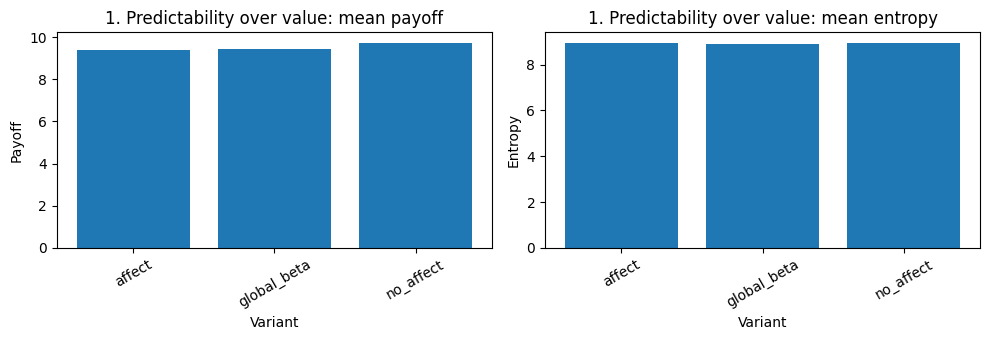

In [23]:
show_demo("predictability_value", predictability_value_results)


## 6. Deployment-Ablation Demo: Run And Analyze

Short analogue of Section 3.2. It keeps the tracked-only lesion and no-epistemic control but drops to 1 seed and 40 rounds.


In [24]:
deployment_ablation_results = run_demo("deployment_ablation")


Demo config: configs/demo/02_deployment_ablation.toml
Paper analogue: configs/paper/02_deployment_ablation.toml
Running: /Users/harshilshah/Desktop/Active Inference/affect_aif/.venv/bin/python scripts/experiment/run.py --config configs/demo/02_deployment_ablation.toml --output-dir outputs --batch-name notebook_demo_02_deployment_ablation --workers 1
Saved 160 rows to outputs/notebook_demo_02_deployment_ablation/deployment_ablation_demo/deployment_ablation_demo/results.csv
Running: /Users/harshilshah/Desktop/Active Inference/affect_aif/.venv/bin/python scripts/analysis/analyze.py --results outputs/notebook_demo_02_deployment_ablation/deployment_ablation_demo/deployment_ablation_demo/results.csv --output-dir outputs/notebook_demo_02_deployment_ablation/deployment_ablation_demo/deployment_ablation_demo/notebook_analysis
Per-variant final summary
  variant_id  mean_total_payoff  std_total_payoff  mean_accuracy
      affect           385.5000               NaN         0.2250
 global_beta   

Rows: 160


experiment_id    variant_id  payoff        q_pi_entropy
                                             mean    sum         mean
0  deployment_ablation_demo        affect  9.6375  385.5     8.885305
1  deployment_ablation_demo   global_beta  9.2250  369.0     8.776910
2  deployment_ablation_demo      lesioned  9.4500  378.0     8.936762
3  deployment_ablation_demo  no_epistemic  9.5500  382.0     9.025794

,variant_id,mean_payoff,total_payoff,mean_entropy
0,affect,9.6375,385.5,8.885305
1,global_beta,9.2250,369.0,8.776910
2,lesioned,9.4500,378.0,8.936762
3,no_epistemic,9.5500,382.0,9.025794


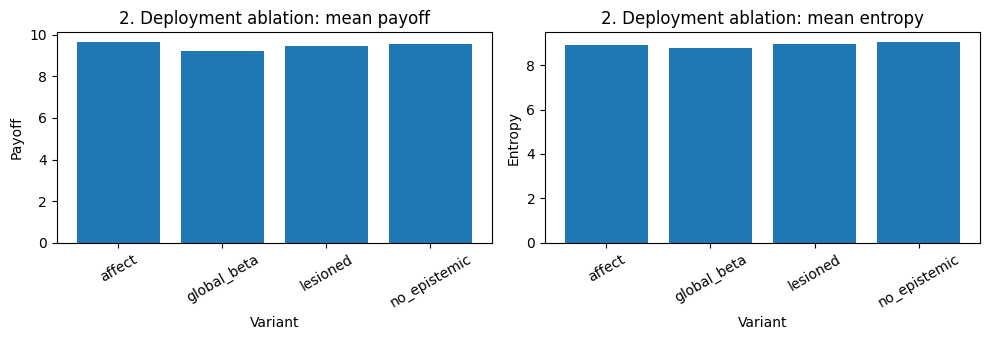

In [25]:
show_demo("deployment_ablation", deployment_ablation_results)


## 7. Partner-Selection Demo: Run And Analyze

Short analogue of Section 3.3. It checks whether the agent-choice pathway runs and exposes partner-selection summaries at demo scale.


In [26]:
partner_selection_results = run_demo("partner_selection")


Demo config: configs/demo/03_partner_selection.toml
Paper analogue: configs/paper/03_partner_selection.toml
Running: /Users/harshilshah/Desktop/Active Inference/affect_aif/.venv/bin/python scripts/experiment/run.py --config configs/demo/03_partner_selection.toml --output-dir outputs --batch-name notebook_demo_03_partner_selection --workers 1
Saved 120 rows to outputs/notebook_demo_03_partner_selection/partner_selection_demo/partner_selection_demo/results.csv
Running: /Users/harshilshah/Desktop/Active Inference/affect_aif/.venv/bin/python scripts/analysis/analyze.py --results outputs/notebook_demo_03_partner_selection/partner_selection_demo/partner_selection_demo/results.csv --output-dir outputs/notebook_demo_03_partner_selection/partner_selection_demo/partner_selection_demo/notebook_analysis
Per-variant final summary
 variant_id  mean_total_payoff  std_total_payoff  mean_accuracy
     affect           417.5000               NaN         0.5000
global_beta           392.0000             

Rows: 120


experiment_id   variant_id   payoff        q_pi_entropy
                                           mean    sum         mean
0  partner_selection_demo       affect  10.4375  417.5     8.398917
1  partner_selection_demo  global_beta   9.8000  392.0     8.839678
2  partner_selection_demo    no_affect   9.9750  399.0     8.864432

,variant_id,mean_payoff,total_payoff,mean_entropy
0,affect,10.4375,417.5,8.398917
1,global_beta,9.8000,392.0,8.839678
2,no_affect,9.9750,399.0,8.864432


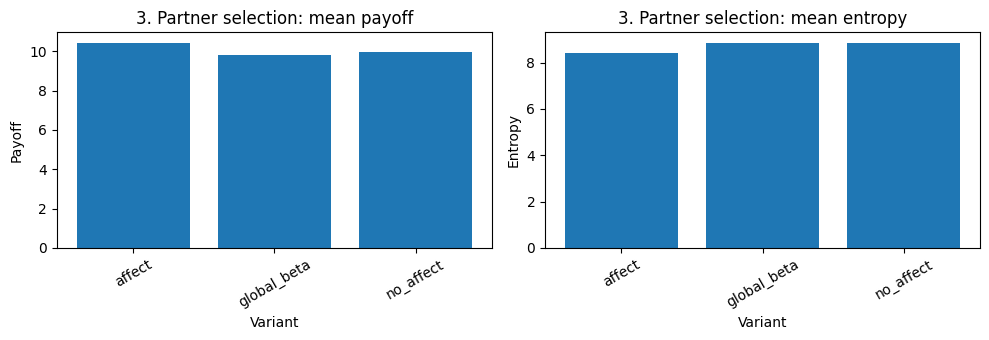

In [27]:
show_demo("partner_selection", partner_selection_results)


## 8. Betrayal-Adaptation Demo: Run And Analyze

Short analogue of Section 3.4. The stance switch happens earlier so the same adaptation path can be inspected quickly.


In [28]:
betrayal_adaptation_results = run_demo("betrayal_adaptation")


Demo config: configs/demo/04_betrayal_adaptation.toml
Paper analogue: configs/paper/04_betrayal_adaptation.toml
Running: /Users/harshilshah/Desktop/Active Inference/affect_aif/.venv/bin/python scripts/experiment/run.py --config configs/demo/04_betrayal_adaptation.toml --output-dir outputs --batch-name notebook_demo_04_betrayal_adaptation --workers 1
Saved 400 rows to outputs/notebook_demo_04_betrayal_adaptation/betrayal_adaptation_demo/betrayal_adaptation_demo/results.csv
Running: /Users/harshilshah/Desktop/Active Inference/affect_aif/.venv/bin/python scripts/analysis/analyze.py --results outputs/notebook_demo_04_betrayal_adaptation/betrayal_adaptation_demo/betrayal_adaptation_demo/results.csv --output-dir outputs/notebook_demo_04_betrayal_adaptation/betrayal_adaptation_demo/betrayal_adaptation_demo/notebook_analysis
Per-variant final summary
 variant_id  mean_total_payoff  std_total_payoff  mean_accuracy
     affect           490.2500           10.2530         0.5400
global_beta      

Rows: 400


experiment_id   variant_id payoff        q_pi_entropy
                                           mean    sum         mean
0  betrayal_adaptation_demo       affect  9.805  980.5     8.509655
1  betrayal_adaptation_demo  global_beta  9.320  932.0     8.852750
2  betrayal_adaptation_demo     lesioned  9.325  932.5     8.903479
3  betrayal_adaptation_demo    no_affect  9.325  932.5     8.903479

,variant_id,mean_payoff,total_payoff,mean_entropy
0,affect,9.805,980.5,8.509655
1,global_beta,9.320,932.0,8.852750
2,lesioned,9.325,932.5,8.903479
3,no_affect,9.325,932.5,8.903479


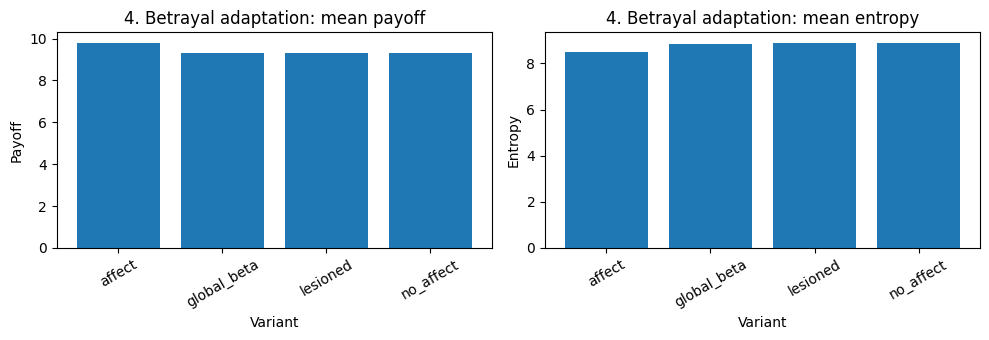

In [29]:
show_demo("betrayal_adaptation", betrayal_adaptation_results)


## 9. Alpha-Sweep Demo: Run And Analyze

Short analogue of the Exp A profile sweep. It keeps open-graded and betrayal sub-experiments but uses three alpha values, 1 seed, and 60 rounds.


In [30]:
alpha_sweep_results = run_demo("alpha_sweep")


Demo config: configs/demo/05a_alpha_sweep.toml
Paper analogue: configs/paper/05a_alpha_sweep.toml
Running: /Users/harshilshah/Desktop/Active Inference/affect_aif/.venv/bin/python scripts/experiment/run.py --config configs/demo/05a_alpha_sweep.toml --output-dir outputs --batch-name notebook_demo_05a_alpha_sweep --workers 1


/Users/harshilshah/Desktop/Active Inference/affect_aif/tasks/trust/pomdp.py:240: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return Agent(


Saved batch outputs to outputs/notebook_demo_05a_alpha_sweep
open_graded: 180 rows -> outputs/notebook_demo_05a_alpha_sweep/exp_a_demo/open_graded/results.csv
betrayal: 180 rows -> outputs/notebook_demo_05a_alpha_sweep/exp_a_demo/betrayal/results.csv
Running: /Users/harshilshah/Desktop/Active Inference/affect_aif/.venv/bin/python scripts/analysis/analyze.py --results outputs/notebook_demo_05a_alpha_sweep/exp_a_demo/betrayal/results.csv --output-dir outputs/notebook_demo_05a_alpha_sweep/exp_a_demo/betrayal/notebook_analysis
Per-variant final summary
variant_id  mean_total_payoff  std_total_payoff  mean_accuracy
 alpha_0p1           603.5000               NaN         0.4833
 alpha_1p0           571.0000               NaN         0.5833
 alpha_8p0           601.5000               NaN         0.4500

Hypothesis summary
hypothesis                        label  available                                                                  summary  primary_metric secondary_metric
        H0      

Rows: 360


experiment_id variant_id     payoff        q_pi_entropy
                                 mean    sum         mean
0      betrayal  alpha_0p1  10.058333  603.5     8.777313
1      betrayal  alpha_1p0   9.516667  571.0     8.829900
2      betrayal  alpha_8p0  10.025000  601.5     8.039908
3   open_graded  alpha_0p1   9.525000  571.5     8.834545
4   open_graded  alpha_1p0   9.525000  571.5     8.999101
5   open_graded  alpha_8p0   9.233333  554.0     8.929557

,variant_id,mean_payoff,total_payoff,mean_entropy
0,alpha_0p1,9.791667,1175.0,8.805929
1,alpha_1p0,9.520833,1142.5,8.914501
2,alpha_8p0,9.629167,1155.5,8.484733


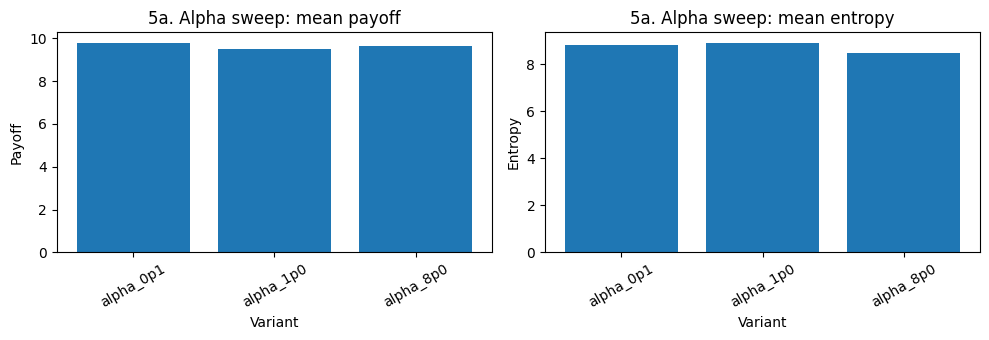

In [31]:
show_demo("alpha_sweep", alpha_sweep_results)


## 10. Optional Prior-Factorial Demo: Run And Analyze

Optional analogue of Exp B. It keeps the open, betrayal, and partner-choice sub-experiments, but uses a reduced profile grid. Set `RUN_OPTIONAL_DEMOS = True` to run it.


In [32]:
prior_factorial_results = run_demo("prior_factorial")


Demo config: configs/demo/05b_prior_factorial.toml
Paper analogue: configs/paper/05b_prior_factorial.toml
Running: /Users/harshilshah/Desktop/Active Inference/affect_aif/.venv/bin/python scripts/experiment/run.py --config configs/demo/05b_prior_factorial.toml --output-dir outputs --batch-name notebook_demo_05b_prior_factorial --workers 1


/Users/harshilshah/Desktop/Active Inference/affect_aif/tasks/trust/pomdp.py:240: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return Agent(


Saved batch outputs to outputs/notebook_demo_05b_prior_factorial
open_graded: 240 rows -> outputs/notebook_demo_05b_prior_factorial/exp_b_demo/open_graded/results.csv
betrayal: 240 rows -> outputs/notebook_demo_05b_prior_factorial/exp_b_demo/betrayal/results.csv
partner_choice: 240 rows -> outputs/notebook_demo_05b_prior_factorial/exp_b_demo/partner_choice/results.csv
Running: /Users/harshilshah/Desktop/Active Inference/affect_aif/.venv/bin/python scripts/analysis/analyze.py --results outputs/notebook_demo_05b_prior_factorial/exp_b_demo/betrayal/results.csv --output-dir outputs/notebook_demo_05b_prior_factorial/exp_b_demo/betrayal/notebook_analysis
Per-variant final summary
        variant_id  mean_total_payoff  std_total_payoff  mean_accuracy
cautious_low_alpha           580.0000               NaN         0.7500
 default_reference           562.0000               NaN         0.4500
  naive_high_alpha           551.0000               NaN         0.3167
         no_affect           569.

Rows: 720


experiment_id          variant_id    payoff        q_pi_entropy
                                            mean    sum         mean
0         betrayal  cautious_low_alpha  9.666667  580.0     9.015729
1         betrayal   default_reference  9.366667  562.0     9.234567
2         betrayal    naive_high_alpha  9.183333  551.0     8.638860
3         betrayal           no_affect  9.483333  569.0     9.068151
4      open_graded  cautious_low_alpha  9.933333  596.0     8.909728
5      open_graded   default_reference  9.333333  560.0     8.689532
6      open_graded    naive_high_alpha  9.516667  571.0     8.528225
7      open_graded           no_affect  9.333333  560.0     8.879151
8   partner_choice  cautious_low_alpha  9.400000  564.0     9.094917
9   partner_choice   default_reference  9.250000  555.0     8.905064
10  partner_choice    naive_high_alpha  9.525000  571.5     8.651442
11  partner_choice           no_affect  9.108333  546.5     8.874066

,variant_id,mean_payoff,total_payoff,mean_entropy
0,cautious_low_alpha,9.666667,1740.0,9.006791
1,default_reference,9.316667,1677.0,8.943054
2,naive_high_alpha,9.408333,1693.5,8.606176
3,no_affect,9.308333,1675.5,8.940456


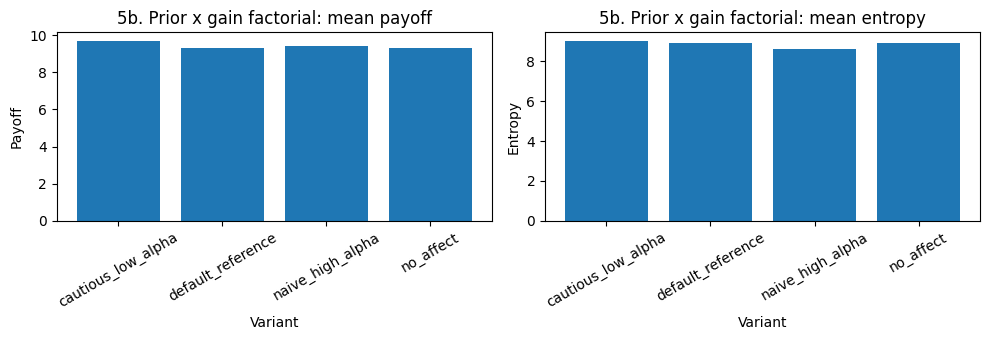

In [33]:
show_demo("prior_factorial", prior_factorial_results)


## 11. Optional Forgiveness Demo: Run And Analyze

Optional analogue of Exp C. It shortens the betrayal/repair schedule and uses a small profile set. Set `RUN_OPTIONAL_DEMOS = True` to run it.


In [34]:
forgiveness_results = run_demo("forgiveness")


Demo config: configs/demo/05c_forgiveness.toml
Paper analogue: configs/paper/05c_forgiveness.toml
Running: /Users/harshilshah/Desktop/Active Inference/affect_aif/.venv/bin/python scripts/experiment/run.py --config configs/demo/05c_forgiveness.toml --output-dir outputs --batch-name notebook_demo_05c_forgiveness --workers 1


/Users/harshilshah/Desktop/Active Inference/affect_aif/tasks/trust/pomdp.py:240: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return Agent(


Saved 180 rows to outputs/notebook_demo_05c_forgiveness/exp_c_demo/forgiveness/results.csv
Running: /Users/harshilshah/Desktop/Active Inference/affect_aif/.venv/bin/python scripts/analysis/analyze.py --results outputs/notebook_demo_05c_forgiveness/exp_c_demo/forgiveness/results.csv --output-dir outputs/notebook_demo_05c_forgiveness/exp_c_demo/forgiveness/notebook_analysis
Per-variant final summary
        variant_id  mean_total_payoff  std_total_payoff  mean_accuracy
cautious_low_alpha           646.5000               NaN         0.0500
 default_reference           560.0000               NaN         0.5833
         no_affect           562.0000               NaN         0.6333

Hypothesis summary
hypothesis                        label  available                                                                  summary  primary_metric secondary_metric
        H0              policy_openness       True                  policy-space openness gates affective precision effects             Na

Rows: 180


experiment_id          variant_id     payoff        q_pi_entropy
                                          mean    sum         mean
0   forgiveness  cautious_low_alpha  10.775000  646.5     8.481614
1   forgiveness   default_reference   9.333333  560.0     8.901395
2   forgiveness           no_affect   9.366667  562.0     8.811282

,variant_id,mean_payoff,total_payoff,mean_entropy
0,cautious_low_alpha,10.775000,646.5,8.481614
1,default_reference,9.333333,560.0,8.901395
2,no_affect,9.366667,562.0,8.811282


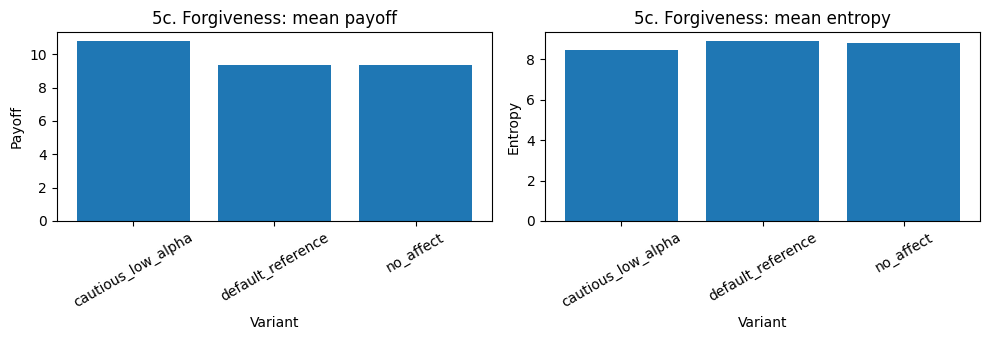

In [35]:
show_demo("forgiveness", forgiveness_results)
